# Dataset description
## Obesity in men and women throughout the years
**Source**: NCD Risk Factor Collaboration (NCD-RisC)

**Download**: [link](https://www.ncdrisc.org/data-downloads-adiposity.html)

# Code
## Imports

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [74]:
path = "./data/NCD_RisC_Nature_2026_BMI_age_standardised_Colombia.csv"

cols = [
    "Year", "Sex", "Prevalence of BMI>=30 kg/m² (obesity)"
]

df = pd.read_csv(path, encoding="utf-8", usecols=cols)

## Clean data

In [75]:
men = (df[(df["Sex"].str.lower().eq("men") & (df["Year"] >= 2000))]
       .set_index("Year")
       .rename(columns={"Prevalence of BMI>=30 kg/m² (obesity)": "Obesity"})
)["Obesity"].mul(100)

women = (df[(df["Sex"].str.lower().eq("women") & (df["Year"] >= 2000))]
       .set_index("Year")
       .rename(columns={"Prevalence of BMI>=30 kg/m² (obesity)": "Obesity"})
)["Obesity"].mul(100)

## Plot

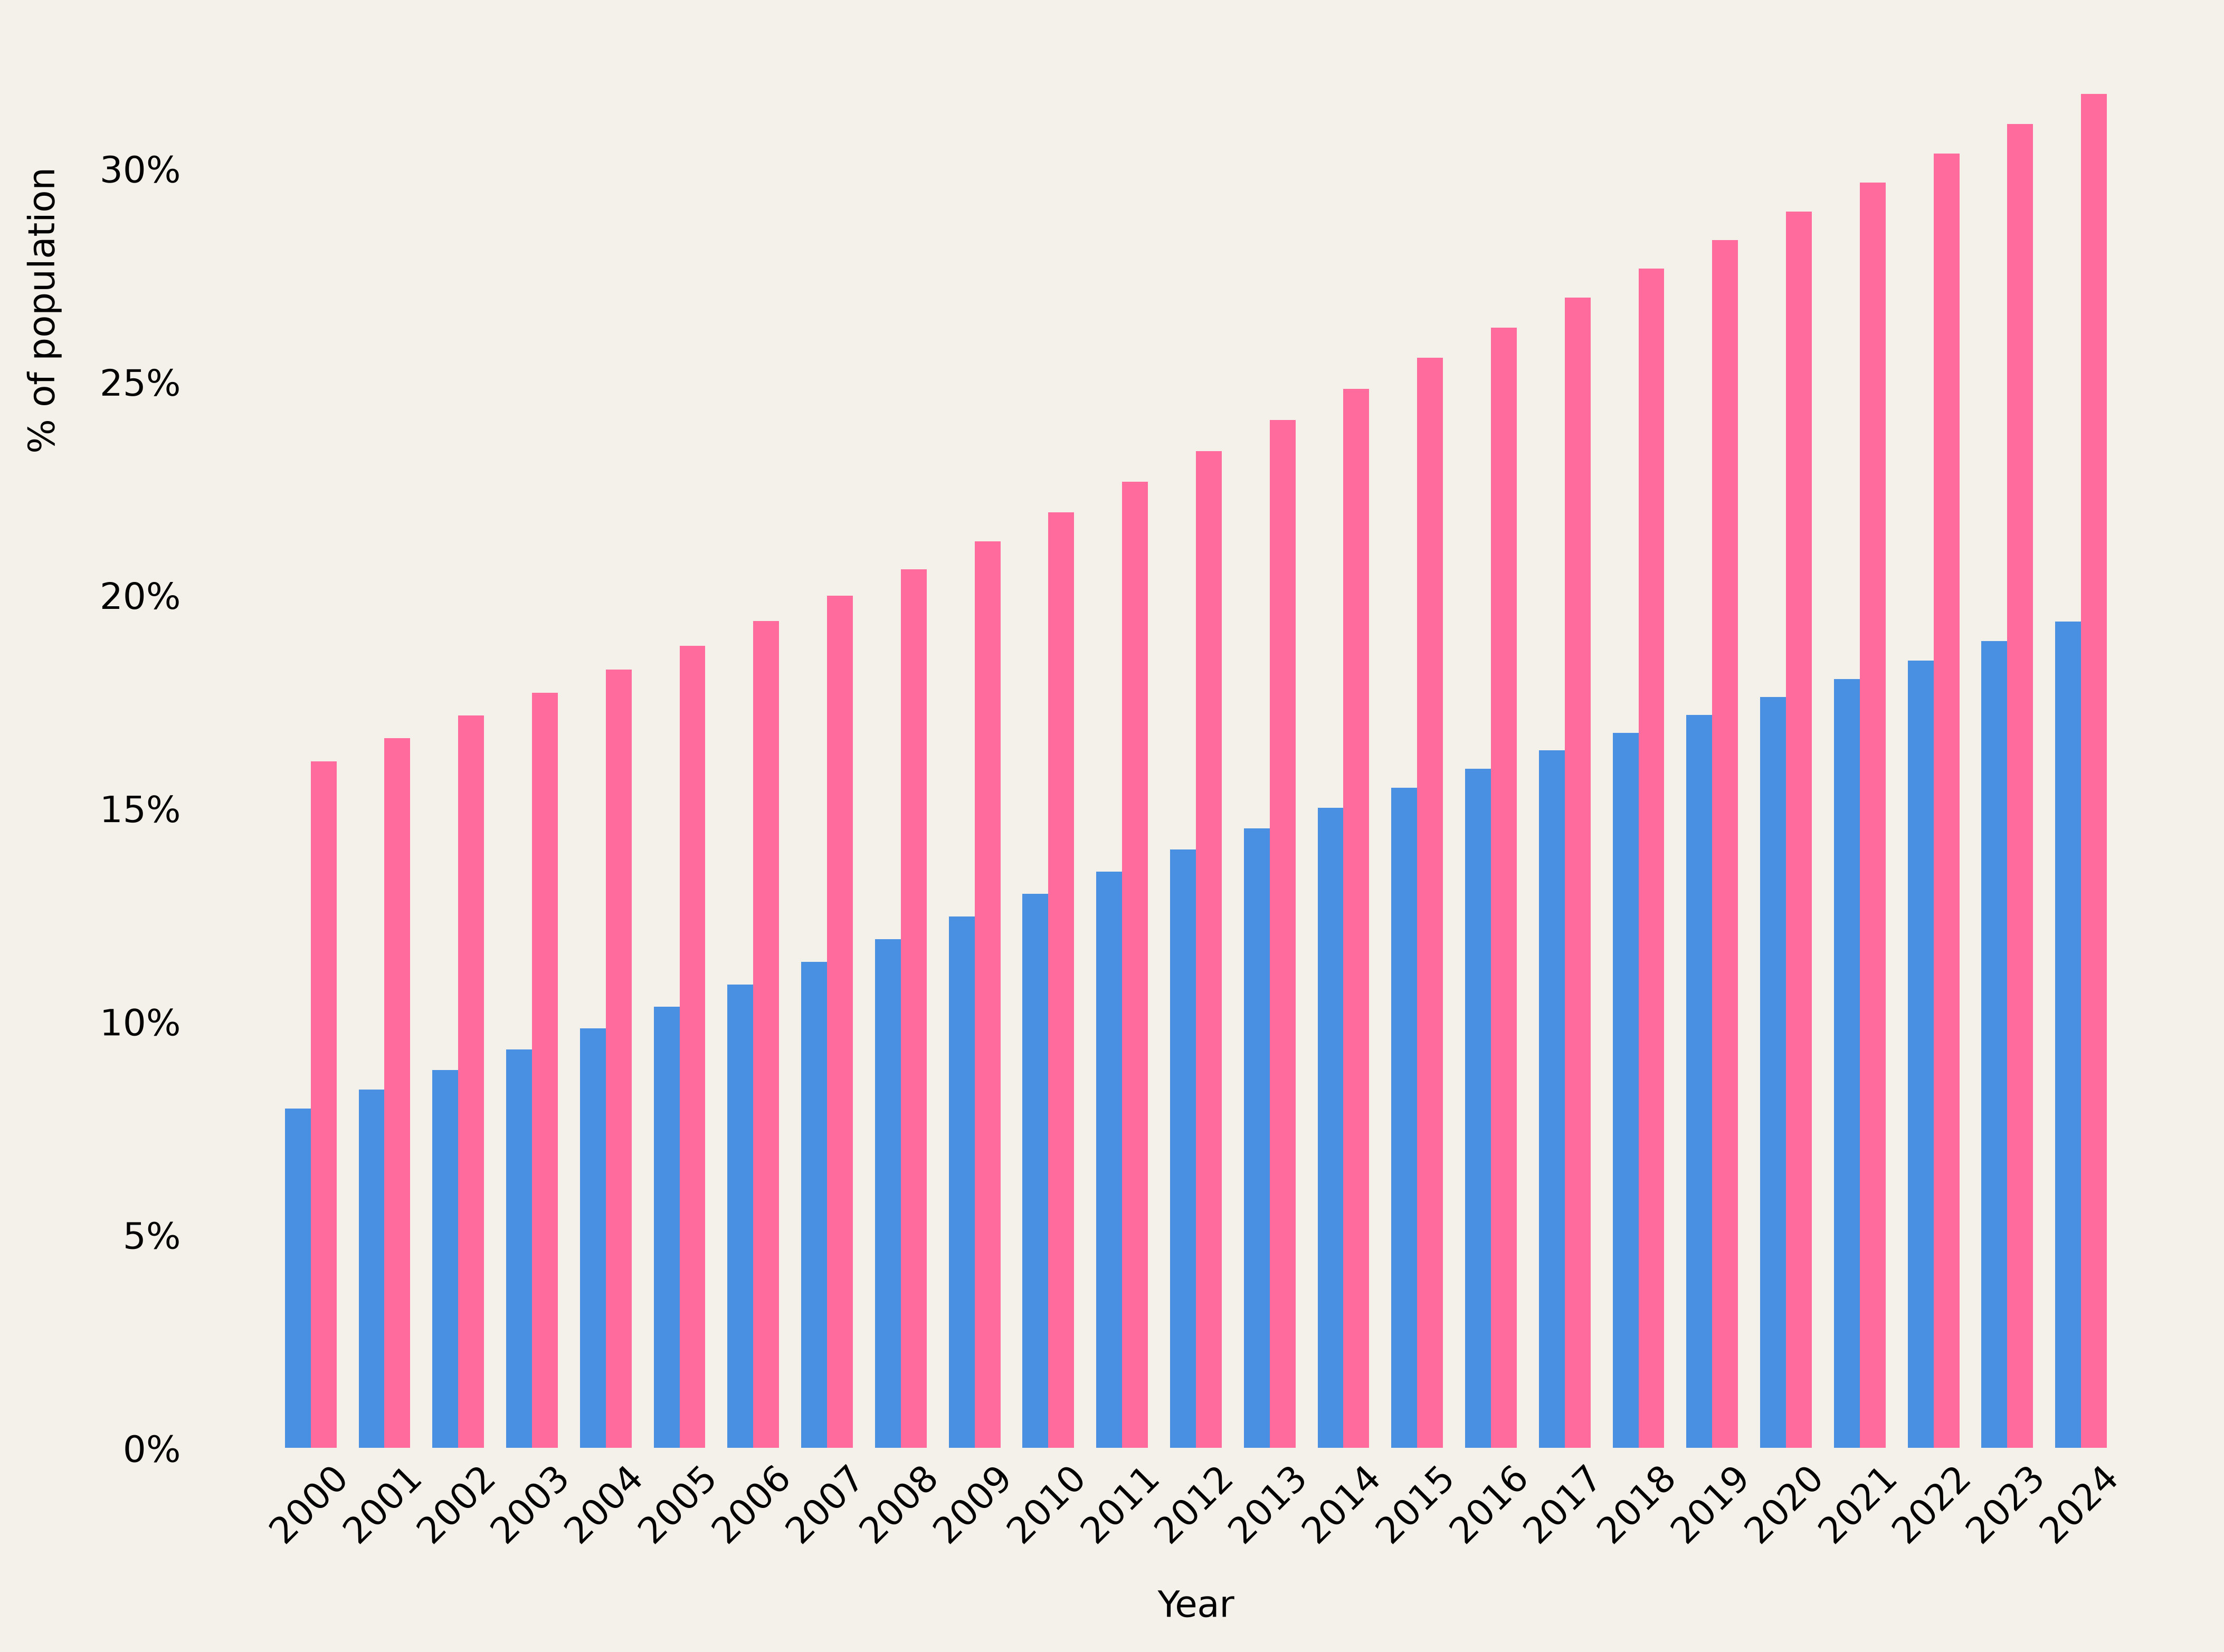

In [87]:
background = "#F4F1EA"
men_color = "#4a90e2"
women_color = "#FF6B9D"

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

width = 0.35
x = range(len(men.index))

plt.bar([i - width/2 for i in x], men.values, width=width, color=men_color)
plt.bar([i + width/2 for i in x], women.values, width=width, color=women_color)

plt.xticks(ticks=x, labels=men.index, rotation=45)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("% of population", labelpad=10, fontsize=10, y=0.8)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.show()